# RT
Load RT data and clean it step by step.

In [235]:
import openpyxl
print(f"openpyxl available: {openpyxl.__version__}")

Note: you may need to restart the kernel to use updated packages.


In [236]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")


def load_rt_data() -> tuple[pd.DataFrame, Path]:
    project_root = resolve_project_root()
    rt_file = project_root / "data" / "raw" / "Alternative Medien" / "RT_de.xlsx"

    frame = pd.read_excel(rt_file)
    frame["source"] = "RT_de"
    frame["source_file"] = rt_file.name
    return frame, rt_file


df, rt_file = load_rt_data()
df_clean = df.copy()

In [237]:
df_clean = df_clean.drop(columns=["Full_Text"], errors="ignore")
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow\n\nDie Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx
...,...,...,...,...,...,...,...,...
12385,2024-11-14,Hauptseite\n/\nSchweiz,Gedemütigt und geschlagen: Was Prostituierte in der Schweiz durchmachen,"Die Realität von Sexarbeiterinnen in der Schweiz bleibt auch heute noch erschreckend: Gewalt, Diskriminierung und sexuelle Übergriffe gehören zum Alltag vie...","Eine aktuelle Studie der Schweizer Organisation ProCoRe verdeutlicht die prekären Umstände, denen diese Frauen ausgesetzt sind.\n\nDie Befragung, die 24 Fra...",https://freedert.online/schweiz/225947-geschlagen-und-gedemuetigt-was-prostituierte/,RT_de,RT_de.xlsx
12386,2024-11-14,Hauptseite\n/\nUkraine-Krieg,Bloomberg: Ukrainer spenden immer weniger für ihre Streitkräfte,"Ukrainische Stiftungen, die die Armee unterstützen, melden starke Rückgänge der Spenden. Angesichts der wirtschaftlichen Schwierigkeiten, Kriegsmüdigkeit un...","Die Bereitschaft der Ukrainer, zur Verteidigung des Landes beizutragen, hat nachgelassen, berichtet die Nachrichtenagentur Bloomberg. Angesichts der Wirtsch...",https://freedert.online/europa/225884-bloomberg-ukrainer-spenden-immer-weniger/,RT_de,RT_de.xlsx
12387,2024-11-14,Hauptseite\n/\nÖsterreich,Österreich: Traditionsmarke Kika/Leiner vor dem Aus,"Ein bitteres Ende für den österreichischen

In [238]:
from IPython.display import display

pd.set_option("display.max_colwidth", 160)

def clean_rt_text_column(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    cleaned["Text"] = (
        cleaned["Text"]
        .astype("string")
        .fillna("")
        .str.replace(r"(?s)\n*\s*Mehr zum Thema.*$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return cleaned


df_clean = clean_rt_text_column(df_clean)

print(f"Loaded {len(df_clean):,} rows from {rt_file}")


Loaded 12,390 rows from /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/RT_de.xlsx


In [239]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
Text,0,0.000000
URL,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [240]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [241]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%Y-%m-%d", errors="coerce")
df_clean.head().assign(Date=df_clean["Date"].dt.strftime("%d-%m-%Y"))


,Date,Category,Title,Summary,Text,URL,source,source_file
0,19-01-2026,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,19-01-2026,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,19-01-2026,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,19-01-2026,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,19-01-2026,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [242]:
start_date = pd.Timestamp("2025-08-01")
end_date = pd.Timestamp("2026-02-01")  # exclusive upper bound

df_clean = df_clean[(df_clean["Date"] >= start_date) & (df_clean["Date"] < end_date)].copy()

In [243]:
# now min/max are real dates
print("min:", df_clean["Date"].min())
print("max:", df_clean["Date"].max())


min: 2025-08-01 00:00:00
max: 2026-01-19 00:00:00


In [244]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4570 entries, 0 to 4569
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4570 non-null   datetime64[us]
 1   Category     4570 non-null   str           
 2   Title        4570 non-null   str           
 3   Summary      4567 non-null   str           
 4   Text         4570 non-null   string        
 5   URL          4570 non-null   str           
 6   source       4570 non-null   str           
 7   source_file  4570 non-null   str           
dtypes: datetime64[us](1), str(6), string(1)
memory usage: 285.8 KB


In [245]:
# Text column already created in the dedicated cleaning cell
df_clean["Text"] = df_clean["Text"].astype("string")


Removal of "Mehr zum Thema"

In [246]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Text"] = df_clean["Text"].apply(remove_mehr_zum_thema)


In [247]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [248]:
#!pip install seaborn


In [249]:
import seaborn as sns
import matplotlib.pyplot as plt


In [250]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    4570.0
mean      582.3
std       410.2
min         0.0
10%       249.9
25%       313.0
50%       421.0
75%       709.8
90%      1208.1
95%      1450.6
99%      1958.0
max      3867.0
Name: article_length_words, dtype: float64

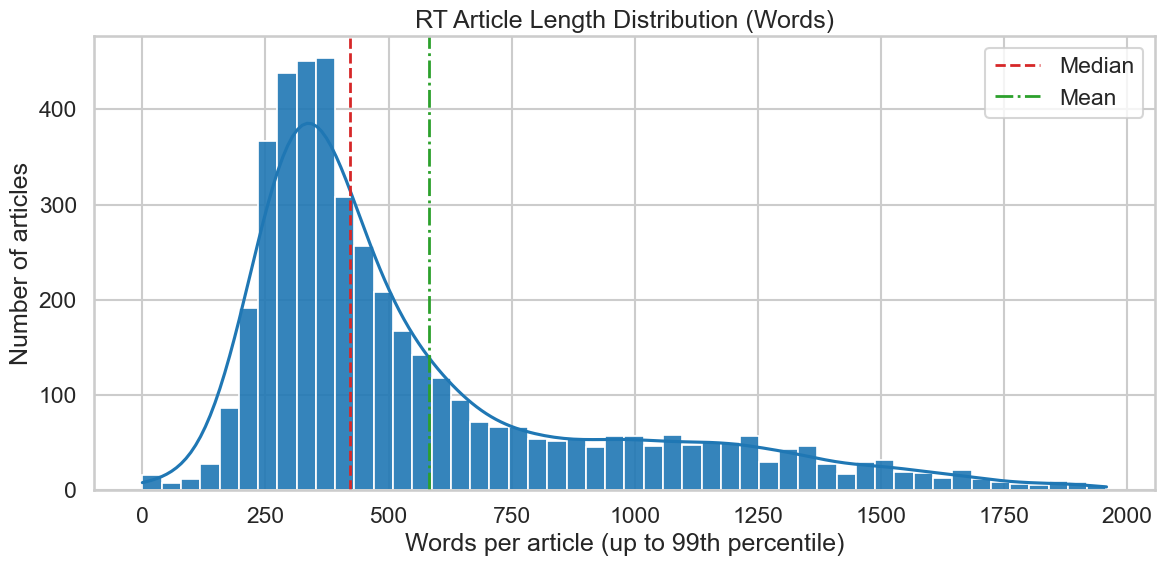

In [251]:
# Plot article length distribution, excluding extreme outliers above the 99th percentile
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


In [252]:
# Compute daily article counts and 7-day rolling average
daily_counts = (
    df_clean.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()


,Date,articles,rolling_7d
0,2025-08-01,15,15.000000
1,2025-08-02,28,21.500000
2,2025-08-03,24,22.333333
3,2025-08-04,26,23.250000
4,2025-08-05,32,25.000000


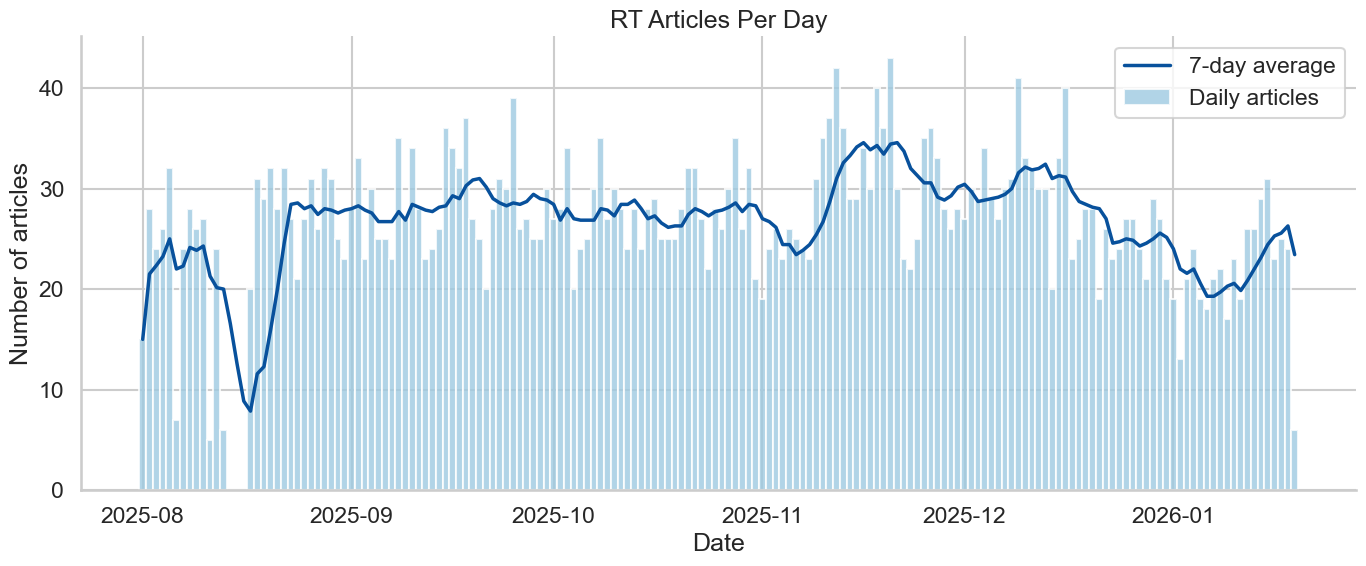

In [253]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


In [254]:
df_clean['Date'].max()

Timestamp('2026-01-19 00:00:00')

Duplicates

In [255]:
# Columns to check for duplicate records
dup_cols = ["Title"]


# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

Number of duplicate rows (across ['Title']): 2


In [256]:
# remove duplicates if either Title OR Inhalt is duplicated
dup_title = df_clean.duplicated(subset=["Title"], keep="first")
dup_text = df_clean.duplicated(subset=["Text"], keep="first")
dup_any = dup_title | dup_text

dups = df_clean.loc[dup_any].copy()      # removed duplicate rows
df_clean = df_clean.loc[~dup_any].copy() # keep only unique rows

print(f"Removed duplicates: {dup_any.sum()}")
print(f"Remaining rows: {len(df_clean)}")

df_clean.head()

Removed duplicates: 10
Remaining rows: 4560


,Date,Category,Title,Summary,Text,URL,source,source_file,article_length_words,article_length_chars
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx,280,1979
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx,423,3091
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx,418,3211
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx,329,2534
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx,965,6979


Save cleaned table for further analysis

In [257]:
rt_de_clean = df_clean[["Date", "Title", "Text", "source"]].copy()
rt_de_clean.to_csv("rt_de_clean.csv", index=False, encoding="utf-8")

## BERTopic 


In [258]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))


In [259]:
from bertopic_pipeline import run_bertopic_pipeline


In [260]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4560 entries, 0 to 4569
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  4560 non-null   datetime64[us]
 1   Category              4560 non-null   str           
 2   Title                 4560 non-null   str           
 3   Summary               4557 non-null   str           
 4   Text                  4560 non-null   str           
 5   URL                   4560 non-null   str           
 6   source                4560 non-null   str           
 7   source_file           4560 non-null   str           
 8   article_length_words  4560 non-null   int64         
 9   article_length_chars  4560 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 391.9 KB


In [261]:
from bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [262]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "1a_BERTopic"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)


cwd: /Users/MattisHaumann/Dev/Thesis/00_Initial EDA
project root added: /Users/MattisHaumann/Dev/Thesis
bertopic module root added: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic


In [263]:
# from BERTopic.bertopic_pipeline import prepare_documents
# from BERTopic.bertopic_config import BERTopicConfig, title_config

# cfg = BERTopicConfig(min_df=5, max_df=0.88)   # or whatever you test
# prep = prepare_documents(df_clean, text_col="Text", config=cfg, id_col="row_id")
# n = len(prep)

# print("prepared docs:", n)
# print("min_df:", cfg.min_df, "max_df:", cfg.max_df)
# print("max_df_docs:", int(cfg.max_df * n) if isinstance(cfg.max_df, float) else cfg.max_df)


In [264]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "00_Initial EDA" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("RT_de")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical RT_de subset from df_combined: {len(df_clean):,} rows")


Loaded canonical RT_de subset from df_combined: 4,560 rows


In [265]:
# Shared RT-specific preprocessing for BERTopic
rt_topic_df = df_clean.copy()
rt_topic_df["topic_text"] = (
    rt_topic_df["Title"].fillna("").astype(str).str.strip()
    + ". "
    + rt_topic_df["Text"].fillna("").astype(str)
).str.strip()
rt_topic_df["topic_text_boosted"] = (
    rt_topic_df["Title"].fillna("").astype(str).str.strip()
    + ". "
    + rt_topic_df["Title"].fillna("").astype(str).str.strip()
    + ". "
    + rt_topic_df["Text"].fillna("").astype(str)
).str.strip()

rt_extra_boilerplate_patterns = BERTopicConfig().boilerplate_patterns + (
    r"(?is)^von\s+(?:[A-ZÄÖÜ][\wÄÖÜäöüß.-]*\s+){1,5}",
    r"(?is)übersetzt aus dem russischen\.?",
    r"(?is)der artikel ist am [^.]{0,220}? zuerst (?:bei|auf) [^.]{0,160}? erschienen\.?",
    r"(?is)pic\.twitter\.com/\w+",
    r"(?im)^meinung\b.*$",
    r"(?im)^video\b.*$",
)
# Keep substantive actors and geopolitical terms in the model.
# Only suppress outlet/formulaic words and generic reporting verbs in c-TF-IDF labels.
rt_extra_stopwords = (
    "meinung", "video", "bilder", "lesen", "artikel", "zuerst", "erschienen",
    "sagte", "sagt", "berichtete", "berichtet", "erklärte", "erklärt", "laut", "zufolge",
    "heute", "gestern",
)

# Iteration 1: text-only with moderate clustering after RT-specific cleanup
result_full_text = run_bertopic_pipeline(
    df=rt_topic_df,
    text_col="Text",
    config=BERTopicConfig(
        boilerplate_patterns=rt_extra_boilerplate_patterns,
        extra_stopwords=rt_extra_stopwords,
        max_df=0.85,
        umap_n_neighbors=20,
        umap_min_dist=0.05,
        hdbscan_min_cluster_size=16,
        hdbscan_min_samples=4,
        hdbscan_cluster_selection_method="eom",
    ),
    id_col="row_id",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 16:59:56,077 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-31 17:00:45,313 - BERTopic - Embedding - Completed ✓
2026-03-31 17:00:45,315 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 17:00:57,872 - BERTopic - Dimensionality - Completed ✓
2026-03-31 17:00:57,877 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 17:00:58,048 - BERTopic - Cluster - Completed ✓
2026-03-31 17:00:58,069 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 17:01:04,333 - BERTopic - Representation - Completed ✓


In [266]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1568,-1_kiew_selenskij_ukrainische_afd,"[kiew, selenskij, ukrainische, afd, china, merz, polen, soldaten, berlin, dollar, armee, streitkräfte, truppen, washington, ukrainer, frieden, the, beziehun...","[Wladimir Putin eine erweiterte Sitzung des Kollegiums des russischen Verteidigungsministeriums ab, bei der er die Ergebnisse des zu Ende gehenden Jahres im..."
1,0,314,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels, iranische, un, geiseln, palästinensischen, idf, saudi, iranisch...","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,237,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, washington, drogen, maduros, trumps, drogenhande...",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,204,2_selenskij_trumps_us präsident_washington,"[selenskij, trumps, us präsident, washington, wladimir putin, verhandlungen, alaska, witkoff, kiew, russischen präsidenten, konflikts, gipfel, beziehungen, ...","[verstehen, wie das gestrige Treffen zwischen US-Präsident Donald Trump und seinem ukrainischen Amtskollegen Wladimir Selenskij sowie Mitgliedern des ""Orden..."
4,3,136,3_china_peking_taiwan_chinas,"[china, peking, taiwan, chinas, chinesischen, chinesische, xi, japan, zölle, beziehungen, jinping, xi jinping, insel, takaichi, indien, erden, df, washingto...","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
5,4,126,4_drohnen_polen_luftraum_drohne,"[drohnen, polen, luftraum, drohne, polnischen, flugzeug, burewestnik, polnische, vorfall, flugzeuge, flughafen, rakete, gps, einsatz, luft, systeme, verteid...",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
6,5,102,5_polizei_verletzt_täter_opfer,"[polizei, verletzt, täter, opfer, jährige, ermittlungen, mann, verletzten, messer, explosion, crans montana, crans, montana, schwer, jähriger, verletzte, kr...",[Für den frühen Samstagabend und den frühen Sonntagmorgen finden sich gleich zwei Polizeimeldungen zu eskalierenden Gewaltsituationen unter Einsatz von Mess...
7,6,99,6_vermögenswerte_milliarden euro_belgien_euroclear,"[vermögenswerte, milliarden euro, belgien, euroclear, gelder, eingefrorenen, kommission, de wever, wever, russischer vermögenswerte, für ukraine, kiew, verm...","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
8,7,72,7_wirtschaft_industrie_bundesregierung_milliarden euro,"[wirtschaft, industrie, bundesregierung, milliarden euro, studie, deutsche wirtschaft, quartal, zahlen, investitionen, vergleich, kosten, hohen, merz, wachs...",[Die Zahl der Unternehmensinsolvenzen in Deutschland ist 2025 auf den höchsten Stand seit elf Jahren angestiegen. 23.900 Firmenpleiten meldet die Wirtschaft...
9,8,71,8_finnland_bip_estland_russen,"[finnland, bip, estland, russen, bedrohung, rutte, ostsee, estnischen, kallas, esten, gegen russland, finnlands, militärische, helsinki, finnischen, beziehu...","[des russischen Sicherheitsrates, Dmitri Medwedew, zog historische Parallelen zwischen den Handlungen der heutigen finnischen Regierung und denen ihrer Vorg..."


In [267]:
#pip install gensim

In [ ]:
import scipy
import gensim

print("scipy", scipy.__version__)
print("gensim", gensim.__version__)


In [269]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


RT_EVAL_TOP_K = 30

def get_topic_words(topic_model, top_k=RT_EVAL_TOP_K, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=RT_EVAL_TOP_K):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=RT_EVAL_TOP_K)
metrics


{'coherence_npmi': -0.053641483538941534,
 'topic_diversity': 0.7424731182795699,
 'num_topics': 62,
 'top_k': 30}

In [270]:
# Legacy exploratory run kept for reference only.
# This was the early balanced title+text trial that later informed the final chosen spec.
# Disabled on purpose so the notebook has one canonical RT fit cell below.
# Tuned here: text_col='topic_text', min_df=2, max_df=0.85, umap_n_neighbors=18,
# umap_min_dist=0.05, hdbscan_min_cluster_size=14, hdbscan_min_samples=4,
# hdbscan_cluster_selection_method='eom'.
# result_full_text = run_bertopic_pipeline(
#     df=rt_topic_df,
#     text_col="topic_text",
#     config=BERTopicConfig(
#         boilerplate_patterns=rt_extra_boilerplate_patterns,
#         extra_stopwords=rt_extra_stopwords,
#         min_df=2,
#         max_df=0.85,
#         umap_n_neighbors=18,
#         umap_min_dist=0.05,
#         hdbscan_min_cluster_size=14,
#         hdbscan_min_samples=4,
#         hdbscan_cluster_selection_method="eom",
#     ),
#     id_col="row_id",
#     source_name="RT_de",
# )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 17:02:00,573 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-31 17:02:35,200 - BERTopic - Embedding - Completed ✓
2026-03-31 17:02:35,203 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 17:02:43,558 - BERTopic - Dimensionality - Completed ✓
2026-03-31 17:02:43,560 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 17:02:43,656 - BERTopic - Cluster - Completed ✓
2026-03-31 17:02:43,659 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 17:02:47,318 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy RT preview disabled. Use the canonical `result` / `result_rt` preview cells below.")


In [272]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=RT_EVAL_TOP_K)
metrics


{'coherence_npmi': -0.053641483538941534,
 'topic_diversity': 0.7424731182795699,
 'num_topics': 62,
 'top_k': 30}

In [273]:
# Legacy exploratory run kept for reference only.
# This was the slightly finer title+text trial used to test whether the baseline was too coarse.
# Disabled on purpose. Parameters varied here were max_df=0.82, umap_n_neighbors=14,
# hdbscan_min_cluster_size=12, and hdbscan_min_samples=3.
# result_full_text = run_bertopic_pipeline(
#     df=rt_topic_df,
#     text_col="topic_text",
#     config=BERTopicConfig(
#         boilerplate_patterns=rt_extra_boilerplate_patterns,
#         extra_stopwords=rt_extra_stopwords,
#         min_df=2,
#         max_df=0.82,
#         umap_n_neighbors=14,
#         umap_min_dist=0.05,
#         hdbscan_min_cluster_size=12,
#         hdbscan_min_samples=3,
#         hdbscan_cluster_selection_method="eom",
#     ),
#     id_col="row_id",
#     source_name="RT_de",
# )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 17:03:20,838 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-31 17:03:55,155 - BERTopic - Embedding - Completed ✓
2026-03-31 17:03:55,157 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 17:04:01,451 - BERTopic - Dimensionality - Completed ✓
2026-03-31 17:04:01,452 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 17:04:01,541 - BERTopic - Cluster - Completed ✓
2026-03-31 17:04:01,544 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 17:04:05,547 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy RT preview disabled. Use the canonical `result` / `result_rt` preview cells below.")


In [275]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=RT_EVAL_TOP_K)
metrics


{'coherence_npmi': -0.053641483538941534,
 'topic_diversity': 0.7424731182795699,
 'num_topics': 62,
 'top_k': 30}

In [276]:
# Legacy exploratory run kept for reference only.
# This was the title-boosted fallback trial used to test whether duplicating the title helped.
# Disabled on purpose. Parameters varied here were text_col='topic_text_boosted' and
# umap_n_neighbors=16 while keeping the rest close to the balanced setup.
# result_full_text = run_bertopic_pipeline(
#     df=rt_topic_df,
#     text_col="topic_text_boosted",
#     config=BERTopicConfig(
#         boilerplate_patterns=rt_extra_boilerplate_patterns,
#         extra_stopwords=rt_extra_stopwords,
#         min_df=2,
#         max_df=0.85,
#         umap_n_neighbors=16,
#         umap_min_dist=0.05,
#         hdbscan_min_cluster_size=14,
#         hdbscan_min_samples=4,
#         hdbscan_cluster_selection_method="eom",
#     ),
#     id_col="row_id",
#     source_name="RT_de",
# )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 17:04:37,893 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-31 17:05:08,205 - BERTopic - Embedding - Completed ✓
2026-03-31 17:05:08,206 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 17:05:15,043 - BERTopic - Dimensionality - Completed ✓
2026-03-31 17:05:15,044 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 17:05:15,125 - BERTopic - Cluster - Completed ✓
2026-03-31 17:05:15,127 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 17:05:18,456 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy RT preview disabled. Use the canonical `result` / `result_rt` preview cells below.")


In [278]:


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=RT_EVAL_TOP_K)
metrics

{'coherence_npmi': -0.053641483538941534,
 'topic_diversity': 0.7424731182795699,
 'num_topics': 62,
 'top_k': 30}

In [279]:
# Canonical final RT run.
# After exploratory trials, we decided to keep the balanced title+text setup.
# The parameters that were tuned/played around with were the text representation
# (`topic_text` vs `topic_text_boosted`), `max_df` (0.82 vs 0.85),
# `umap_n_neighbors` (14 / 16 / 18), `hdbscan_min_cluster_size` (12 vs 14),
# and `hdbscan_min_samples` (3 vs 4), while keeping the RT-specific boilerplate
# cleanup and extra stopwords.
# Final choice: topic_text + min_df=2 + max_df=0.85 + umap_n_neighbors=18
# + umap_min_dist=0.05 + hdbscan_min_cluster_size=20 + hdbscan_min_samples=4
# + hdbscan_cluster_selection_method='eom'.
result_full_text = run_bertopic_pipeline(
    df=rt_topic_df,
    text_col="topic_text",
    config=BERTopicConfig(
        boilerplate_patterns=rt_extra_boilerplate_patterns,
        extra_stopwords=rt_extra_stopwords,
        min_df=2,
        max_df=0.85,
        umap_n_neighbors=18,
        umap_min_dist=0.05,
        hdbscan_min_cluster_size=20,  # raised from 14; ~45-50 topics, more proportional to corpus size
        hdbscan_min_samples=4,
        hdbscan_cluster_selection_method="eom",
    ),
    id_col="row_id",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 17:05:49,356 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-31 17:06:18,142 - BERTopic - Embedding - Completed ✓
2026-03-31 17:06:18,147 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 17:06:25,253 - BERTopic - Dimensionality - Completed ✓
2026-03-31 17:06:25,254 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 17:06:25,337 - BERTopic - Cluster - Completed ✓
2026-03-31 17:06:25,339 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 17:06:28,776 - BERTopic - Representation - Completed ✓


In [280]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1425,-1_nato_putin_ukrainischen_china,"[nato, putin, ukrainischen, china, kiew, selenskij, ukrainische, soldaten, europäische, merz, sanktionen, streitkräfte, polen, armee, berlin, russischer, st...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,312,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, geiseln, iranische, palästinensischen, idf, iranischen, kat...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,224,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, machado, drogen, maduros, trumps, drogenhandel, ...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,205,2_afd_spd_cdu_partei,"[afd, spd, cdu, partei, grünen, bsw, habeck, weidel, demokratie, bundestag, bank, parteien, merz, kandidaten, corona, umfrage, stimmen, fraktion, bürger, wa...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,148,3_nato_putin_kiew_ukrainischen,"[nato, putin, kiew, ukrainischen, selenskij, ukrainer, ukrainische, verhandlungen, russen, armee, konflikts, frieden, gegen russland, westlichen, wladimir p...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,106,4_drohnen_polen_nato_drohne,"[drohnen, polen, nato, drohne, luftraum, gps, flugzeug, polnischen, vorfall, russische drohnen, polnische, flughafen, ukrainische, bundeswehr, flugzeuge, ei...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,69,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, jermak, ukrainischen, korruption, kolomoiski, korruptionsskandal, ukrainische, energoatom, rücktritt, timur, kiew, ...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,69,6_ukrainischen_streitkräfte_stadt_ukrainische,"[ukrainischen, streitkräfte, stadt, ukrainische, truppen, kupjansk, gebiet, liman, frontabschnitt, pokrowsk, front, ukrainischen streitkräfte, kramatorsk, k...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,68,7_putin_gipfel_budapest_selenskij,"[putin, gipfel, budapest, selenskij, putin trump, alaska, stattfinden, wladimir putin, gipfeltreffen, treffens, uschakow, verhandlungen, trump putin, ungarn...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Regierungschefs der Europäischen Union wollen bei dem bevorstehen...
9,8,63,8_trumps_kiew_putin_nato,"[trumps, kiew, putin, nato, selenskij, weißen, haus, europäer, ukrainischen, weißen haus, verhandlungen, sanktionen, position, konflikts, medwedew, amerikan...","[Ukraine – Trump setzt mit starkem Zug EU-NATO-Falken matt. Von Rainer Rupp Dank seiner Bereitschaft, direkte Gespräche mit der russischen Seite zu führen, ..."


In [281]:
# Save topics from the current BERTopic run
topics_out = PROJECT_ROOT / "1a_BERTopic" / "outputs" / "rt_topics_current_run.csv"
topics_out.parent.mkdir(parents=True, exist_ok=True)

result["topic_info"].to_csv(topics_out, index=False, encoding="utf-8-sig")
print(f"Saved topic table to: {topics_out}")

Saved topic table to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/outputs/rt_topics_current_run.csv


In [282]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=RT_EVAL_TOP_K)
metrics

{'coherence_npmi': -0.0449436983524929,
 'topic_diversity': 0.713963963963964,
 'num_topics': 74,
 'top_k': 30}

## Selected RT Baseline

The canonical RT model is the final run from the cell above. Earlier trial runs are kept in the notebook as disabled reference cells only.

By default this section reuses the latest RT BERTopic run already stored in `result` (the one you just inspected/plotted).

Set `RT_BASELINE_SOURCE = "saved_model"` only when you intentionally want to load the saved artifact from `1a_BERTopic/outputs/rt_model`.


In [283]:
from pathlib import Path
import pandas as pd
from bertopic_pipeline import prepare_documents
from bertopic_config import BERTopicConfig
from bertopic import BERTopic

# Default: keep using the latest RT BERTopic run already stored in `result`.
# Switch to "saved_model" only if you explicitly want the artifact on disk.
RT_BASELINE_SOURCE = "latest_run"  # "latest_run" | "saved_model"

# Must mirror the final RT fit cell above when `saved_model` is used.
rt_baseline_boilerplate_patterns = BERTopicConfig().boilerplate_patterns + (
    r"(?is)^von\s+(?:[A-ZÄÖÜ][\wÄÖÜäöüß.-]*\s+){1,5}",
    r"(?is)übersetzt aus dem russischen\.?",
    r"(?is)der artikel ist am [^.]{0,220}? zuerst (?:bei|auf) [^.]{0,160}? erschienen\.?",
    r"(?is)pic\.twitter\.com/\w+",
    r"(?im)^meinung\b.*$",
    r"(?im)^video\b.*$",
)
rt_baseline_stopwords = (
    "meinung", "video", "bilder", "lesen", "artikel", "zuerst", "erschienen",
    "sagte", "sagt", "berichtete", "berichtet", "erklärte", "erklärt", "laut", "zufolge",
    "heute", "gestern",
)

rt_config = BERTopicConfig(
    boilerplate_patterns=rt_baseline_boilerplate_patterns,
    extra_stopwords=rt_baseline_stopwords,
    min_df=2,
    max_df=0.85,
    umap_n_neighbors=18,
    umap_min_dist=0.05,
    hdbscan_min_cluster_size=14,
    hdbscan_min_samples=4,
    hdbscan_cluster_selection_method="eom",
)

MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "1a_BERTopic" / "outputs",
]

if RT_BASELINE_SOURCE == "latest_run":
    if "result" not in globals():
        raise RuntimeError(
            "No in-memory `result` found. Run the BERTopic fit cell above or switch "
            "RT_BASELINE_SOURCE to 'saved_model'."
        )

    result_rt = {
        **result,
        "docs": list(result["docs"]),
        "topics": list(result["topics"]),
        "topic_info": result["topic_info"].copy(),
        "doc_info": result["doc_info"].copy(),
    }
    rt_model = result_rt["topic_model"]
    docs_rt_loaded = list(result_rt["docs"])
    topics_rt_loaded = list(result_rt["topics"])
    topic_info_rt_loaded = result_rt["topic_info"].copy()
    doc_info_rt_loaded = result_rt["doc_info"].copy()
    print("Using the latest in-memory RT BERTopic run from `result` as the downstream baseline.")
elif RT_BASELINE_SOURCE == "saved_model":
    rt_model_path = next(
        (candidate / "rt_model" for candidate in MODEL_DIR_CANDIDATES if (candidate / "rt_model").exists()),
        None,
    )
    if rt_model_path is None:
        raise FileNotFoundError(
            "Could not find saved rt_model in: " + ", ".join(str(path) for path in MODEL_DIR_CANDIDATES)
        )
    rt_model = BERTopic.load(rt_model_path)

    rt_topic_df = df_clean.copy()
    rt_topic_df["topic_text"] = (
        rt_topic_df["Title"].fillna("").astype(str).str.strip()
        + ". "
        + rt_topic_df["Text"].fillna("").astype(str)
    ).str.strip()

    prepared_rt = prepare_documents(
        rt_topic_df,
        text_col="topic_text",
        config=rt_config,
        id_col="row_id",
        source_name="RT_de",
    )
    docs_rt_loaded = prepared_rt["document"].tolist()

    topics_attr = list(getattr(rt_model, "topics_", []) or [])
    if len(topics_attr) == len(docs_rt_loaded):
        topics_rt_loaded = topics_attr
    else:
        topics_rt_loaded, _ = rt_model.transform(docs_rt_loaded)
        topics_rt_loaded = list(topics_rt_loaded)
        print(
            "Warning: loaded model topics_ length did not match prepared docs; "
            "used transform(...) assignments."
        )

    rt_model.topics_ = list(topics_rt_loaded)
    if hasattr(rt_model, "probabilities_"):
        rt_model.probabilities_ = None

    topic_info_rt_loaded = rt_model.get_topic_info()

    try:
        doc_info_rt_loaded = rt_model.get_document_info(docs_rt_loaded)
    except Exception as exc:
        topic_name_map = dict(zip(topic_info_rt_loaded["Topic"], topic_info_rt_loaded["Name"]))
        doc_info_rt_loaded = pd.DataFrame({
            "Document": docs_rt_loaded,
            "Topic": topics_rt_loaded,
        })
        doc_info_rt_loaded["Name"] = doc_info_rt_loaded["Topic"].map(topic_name_map)
        print(f"Warning: get_document_info fallback used ({exc}).")

    doc_info_rt_loaded = pd.concat(
        [
            prepared_rt[["original_index", "document_id", "source_name"]].reset_index(drop=True),
            doc_info_rt_loaded.reset_index(drop=True),
        ],
        axis=1,
    )

    result_rt = {
        "config": rt_config,
        "prepared_documents": prepared_rt,
        "docs": docs_rt_loaded,
        "topic_model": rt_model,
        "topics": list(topics_rt_loaded),
        "probabilities": None,
        "topic_info": topic_info_rt_loaded,
        "doc_info": doc_info_rt_loaded,
    }
    print(f"Loaded RT model from: {rt_model_path}")
else:
    raise ValueError("RT_BASELINE_SOURCE must be 'latest_run' or 'saved_model'.")

# Keep the model assignments aligned with the selected baseline docs.
rt_model.topics_ = list(topics_rt_loaded)
result_rt["topic_model"] = rt_model
result_rt["docs"] = list(docs_rt_loaded)
result_rt["topics"] = list(topics_rt_loaded)
result_rt["topic_info"] = topic_info_rt_loaded.copy()
result_rt["doc_info"] = doc_info_rt_loaded.copy()

baseline_outlier_row = result_rt["topic_info"].loc[
    result_rt["topic_info"]["Topic"] == -1,
    ["Topic", "Count", "Name"],
].copy()
display(baseline_outlier_row)


Using the latest in-memory RT BERTopic run from `result` as the downstream baseline.


,Topic,Count,Name
0,-1,1425,-1_nato_putin_ukrainischen_china


In [284]:
topic_info_rt = result_rt["topic_info"]
topic_info_rt.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1425,-1_nato_putin_ukrainischen_china,"[nato, putin, ukrainischen, china, kiew, selenskij, ukrainische, soldaten, europäische, merz, sanktionen, streitkräfte, polen, armee, berlin, russischer, st...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,312,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, geiseln, iranische, palästinensischen, idf, iranischen, kat...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,224,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, machado, drogen, maduros, trumps, drogenhandel, ...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,205,2_afd_spd_cdu_partei,"[afd, spd, cdu, partei, grünen, bsw, habeck, weidel, demokratie, bundestag, bank, parteien, merz, kandidaten, corona, umfrage, stimmen, fraktion, bürger, wa...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,148,3_nato_putin_kiew_ukrainischen,"[nato, putin, kiew, ukrainischen, selenskij, ukrainer, ukrainische, verhandlungen, russen, armee, konflikts, frieden, gegen russland, westlichen, wladimir p...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,106,4_drohnen_polen_nato_drohne,"[drohnen, polen, nato, drohne, luftraum, gps, flugzeug, polnischen, vorfall, russische drohnen, polnische, flughafen, ukrainische, bundeswehr, flugzeuge, ei...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,69,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, jermak, ukrainischen, korruption, kolomoiski, korruptionsskandal, ukrainische, energoatom, rücktritt, timur, kiew, ...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,69,6_ukrainischen_streitkräfte_stadt_ukrainische,"[ukrainischen, streitkräfte, stadt, ukrainische, truppen, kupjansk, gebiet, liman, frontabschnitt, pokrowsk, front, ukrainischen streitkräfte, kramatorsk, k...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,68,7_putin_gipfel_budapest_selenskij,"[putin, gipfel, budapest, selenskij, putin trump, alaska, stattfinden, wladimir putin, gipfeltreffen, treffens, uschakow, verhandlungen, trump putin, ungarn...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Regierungschefs der Europäischen Union wollen bei dem bevorstehen...
9,8,63,8_trumps_kiew_putin_nato,"[trumps, kiew, putin, nato, selenskij, weißen, haus, europäer, ukrainischen, weißen haus, verhandlungen, sanktionen, position, konflikts, medwedew, amerikan...","[Ukraine – Trump setzt mit starkem Zug EU-NATO-Falken matt. Von Rainer Rupp Dank seiner Bereitschaft, direkte Gespräche mit der russischen Seite zu führen, ..."


In [285]:
# Safety switch: save the currently selected baseline only if you explicitly enable it.
SAVE_BASELINE_RT_MODEL = False

rt_model = result_rt["topic_model"]
rt_model_path = PROJECT_ROOT / "1a_BERTopic" / "outputs" / "rt_model"
rt_model_path.parent.mkdir(parents=True, exist_ok=True)

if SAVE_BASELINE_RT_MODEL:
    rt_model.save(
        rt_model_path,
        serialization="safetensors",   # more robust than pickle
        save_ctfidf=True,
        save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    )
    print(f"Saved baseline RT model to: {rt_model_path}")
else:
    print(f"Skipped baseline save (SAVE_BASELINE_RT_MODEL={SAVE_BASELINE_RT_MODEL}).")


Skipped baseline save (SAVE_BASELINE_RT_MODEL=False).


### Outlier Reduction (focused section)

This section starts from the selected RT topic model (`result_rt`) from the baseline section above and keeps the reduction workflow compact.

> **Final downstream workflow:** use the canonical final RT fit above, then apply `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`.


In [286]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_rt).
base_result = result_rt
topic_model_base = base_result["topic_model"]
docs_rt = list(base_result["docs"])
topics_rt = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_rt if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_rt,
    topics_rt,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_rt,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_rt_reduced = dict(base_result)
result_rt_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_rt_reduced["topic_model"] = topic_model_ctfidf_threshold
result_rt_reduced["topic_info"] = topic_info_ctfidf_threshold
result_rt_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_rt_reduced["doc_info"] = doc_info_reduced
result_rt_reduced["display_topic_map"] = display_topic_map
result_rt_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_rt) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)

display(
    base_result["topic_info"].loc[
        base_result["topic_info"]["Topic"] == -1,
        ["Topic", "Count", "Name"],
    ].reset_index(drop=True)
)
display(
    topic_info_ctfidf_threshold.loc[
        topic_info_ctfidf_threshold["Topic"] == -1,
        ["Topic", "Count", "Name"],
    ].reset_index(drop=True)
)
display(topic_info_ctfidf_threshold.head(20))


2026-03-31 17:06:59,807 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,1425,74
1,ctfidf_threshold_0.10,552,74


,Topic,Count,Name
0,-1,1425,-1_nato_putin_ukrainischen_china


,Topic,Count,Name
0,-1,552,-1_berlin_stadt_kinder_soros


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_berlin_stadt_kinder_soros,-1,552,-1_berlin_stadt_kinder_soros,"[berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeit...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,1,Topic 1 — israel_gaza_hamas_iran,israel_gaza_hamas_iran,0,326,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, iranische, geiseln, teheran, idf, iranischen, palästinensis...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,4,Topic 4 — venezuela_maduro_venezuelas_venezolanischen,venezuela_maduro_venezuelas_venezolanischen,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, machado, drogen, maduros, trumps, kuba, drogenha...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,2,Topic 2 — afd_cdu_spd_partei,afd_cdu_spd_partei,2,242,2_afd_cdu_spd_partei,"[afd, cdu, spd, partei, bsw, grünen, corona, weidel, habeck, demokratie, bundestag, merz, parteien, kandidaten, bank, stimmen, umfrage, chrupalla, fraktion,...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,3,Topic 3 — putin_kiew_kallas_selenskij,putin_kiew_kallas_selenskij,3,234,3_putin_kiew_kallas_selenskij,"[putin, kiew, kallas, selenskij, russen, armee, ukrainische, streitkräfte, ukrainer, gegen russland, konflikts, truppen, europas, verhandlungen, wladimir pu...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,5,Topic 5 — drohnen_polen_luftraum_polnischen,drohnen_polen_luftraum_polnischen,4,132,4_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeug, gps, ukrainische, vorfall, polnische, russische drohnen, flugzeuge, bundeswehr, einsatz, abgeschoss...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,8,Topic 8 — selenskij_nabu_minditsch_selenskijs,selenskij_nabu_minditsch_selenskijs,5,89,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, korruption, jermak, korruptionsskandal, ukrainische, kolomoiski, kiew, timur, energoatom, wladimir selenskij, umero...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,6,Topic 6 — stadt_streitkräfte_ukrainische_truppen,stadt_streitkräfte_ukrainische_truppen,6,113,6_stadt_streitkräfte_ukrainische_truppen,"[stadt, streitkräfte, ukrainische, truppen, ukrainischen streitkräfte, pokrowsk, kupjansk, saporoschje, gebiet, front, konstantinowka, liman, slawjansk, fro...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,7,Topic 7 — putin_selenskij_gipfel_putin trump,putin_selenskij_gipfel_putin trump,7,94,7_putin_selenskij_gipfel_putin trump,"[putin, selenskij, gipfel, putin trump, budapest, alaska, wladimir putin, gipfeltreffen, stattfinden, verhandlungen, staatschefs, uschakow, konflikts, treff...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Reg

In [287]:
from pathlib import Path
import shutil

# Save the exact RT result object used downstream and in the display cells below.
final_rt_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
result_rt = final_rt_result
rt_model_to_save = final_rt_result["topic_model"]

save_dir = PROJECT_ROOT / "1a_BERTopic" / "outputs" / "rt_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

rt_model_to_save.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")


Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/outputs/rt_model


In [288]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_berlin_stadt_kinder_soros,-1,552,-1_berlin_stadt_kinder_soros,"[berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeit...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,1,Topic 1 — israel_gaza_hamas_iran,israel_gaza_hamas_iran,0,326,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, iranische, geiseln, teheran, idf, iranischen, palästinensis...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,4,Topic 4 — venezuela_maduro_venezuelas_venezolanischen,venezuela_maduro_venezuelas_venezolanischen,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, machado, drogen, maduros, trumps, kuba, drogenha...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,2,Topic 2 — afd_cdu_spd_partei,afd_cdu_spd_partei,2,242,2_afd_cdu_spd_partei,"[afd, cdu, spd, partei, bsw, grünen, corona, weidel, habeck, demokratie, bundestag, merz, parteien, kandidaten, bank, stimmen, umfrage, chrupalla, fraktion,...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,3,Topic 3 — putin_kiew_kallas_selenskij,putin_kiew_kallas_selenskij,3,234,3_putin_kiew_kallas_selenskij,"[putin, kiew, kallas, selenskij, russen, armee, ukrainische, streitkräfte, ukrainer, gegen russland, konflikts, truppen, europas, verhandlungen, wladimir pu...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,5,Topic 5 — drohnen_polen_luftraum_polnischen,drohnen_polen_luftraum_polnischen,4,132,4_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeug, gps, ukrainische, vorfall, polnische, russische drohnen, flugzeuge, bundeswehr, einsatz, abgeschoss...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,8,Topic 8 — selenskij_nabu_minditsch_selenskijs,selenskij_nabu_minditsch_selenskijs,5,89,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, korruption, jermak, korruptionsskandal, ukrainische, kolomoiski, kiew, timur, energoatom, wladimir selenskij, umero...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,6,Topic 6 — stadt_streitkräfte_ukrainische_truppen,stadt_streitkräfte_ukrainische_truppen,6,113,6_stadt_streitkräfte_ukrainische_truppen,"[stadt, streitkräfte, ukrainische, truppen, ukrainischen streitkräfte, pokrowsk, kupjansk, saporoschje, gebiet, front, konstantinowka, liman, slawjansk, fro...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,7,Topic 7 — putin_selenskij_gipfel_putin trump,putin_selenskij_gipfel_putin trump,7,94,7_putin_selenskij_gipfel_putin trump,"[putin, selenskij, gipfel, putin trump, budapest, alaska, wladimir putin, gipfeltreffen, stattfinden, verhandlungen, staatschefs, uschakow, konflikts, treff...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Reg

### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


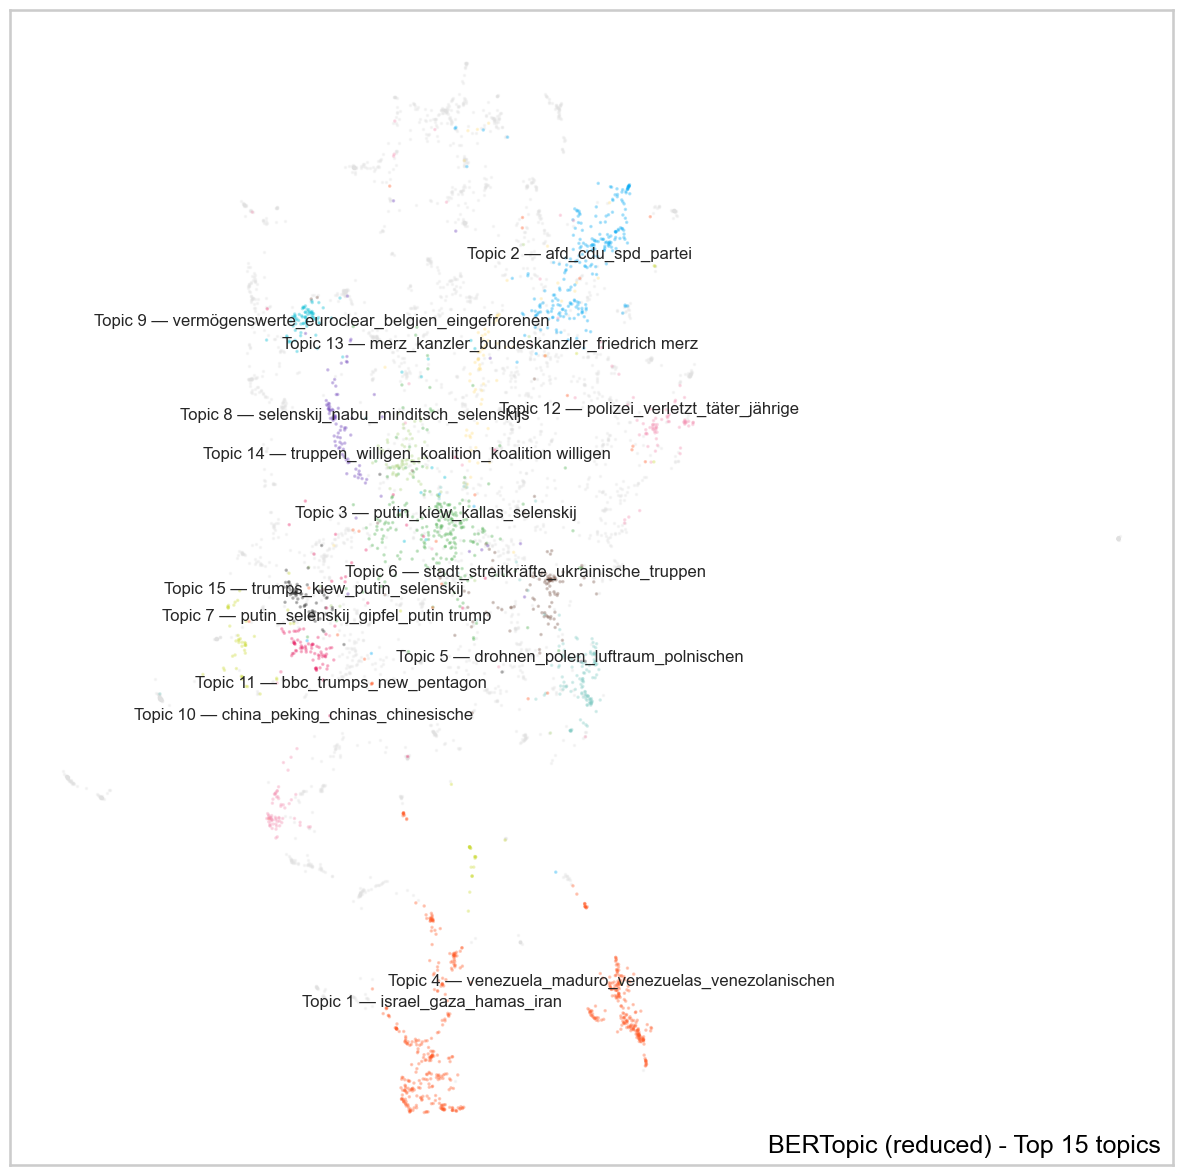

In [289]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()


## Topics Over Time

Uses `result_rt_reduced` if you have already run the outlier-reduction cell; otherwise it falls back to the selected baseline `result_rt`.


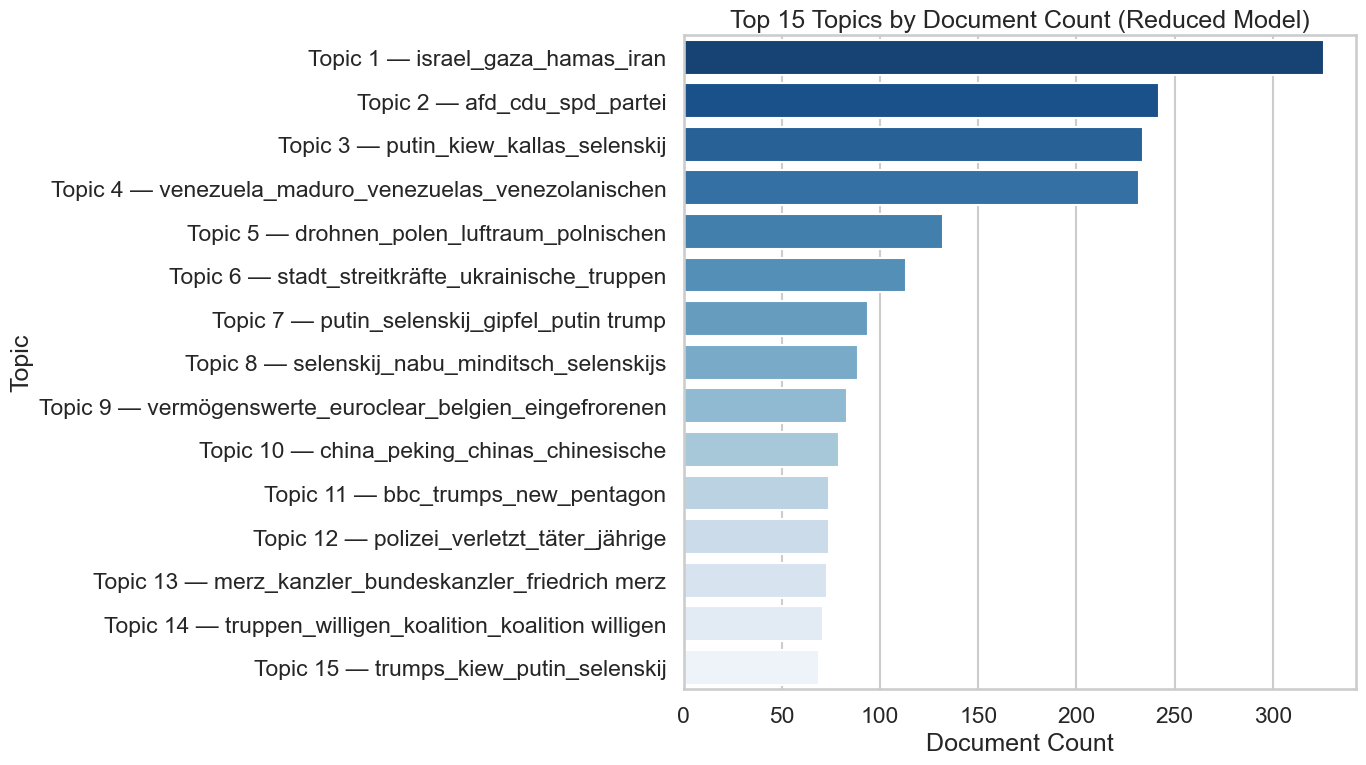

In [290]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()


6it [00:15,  2.62s/it]


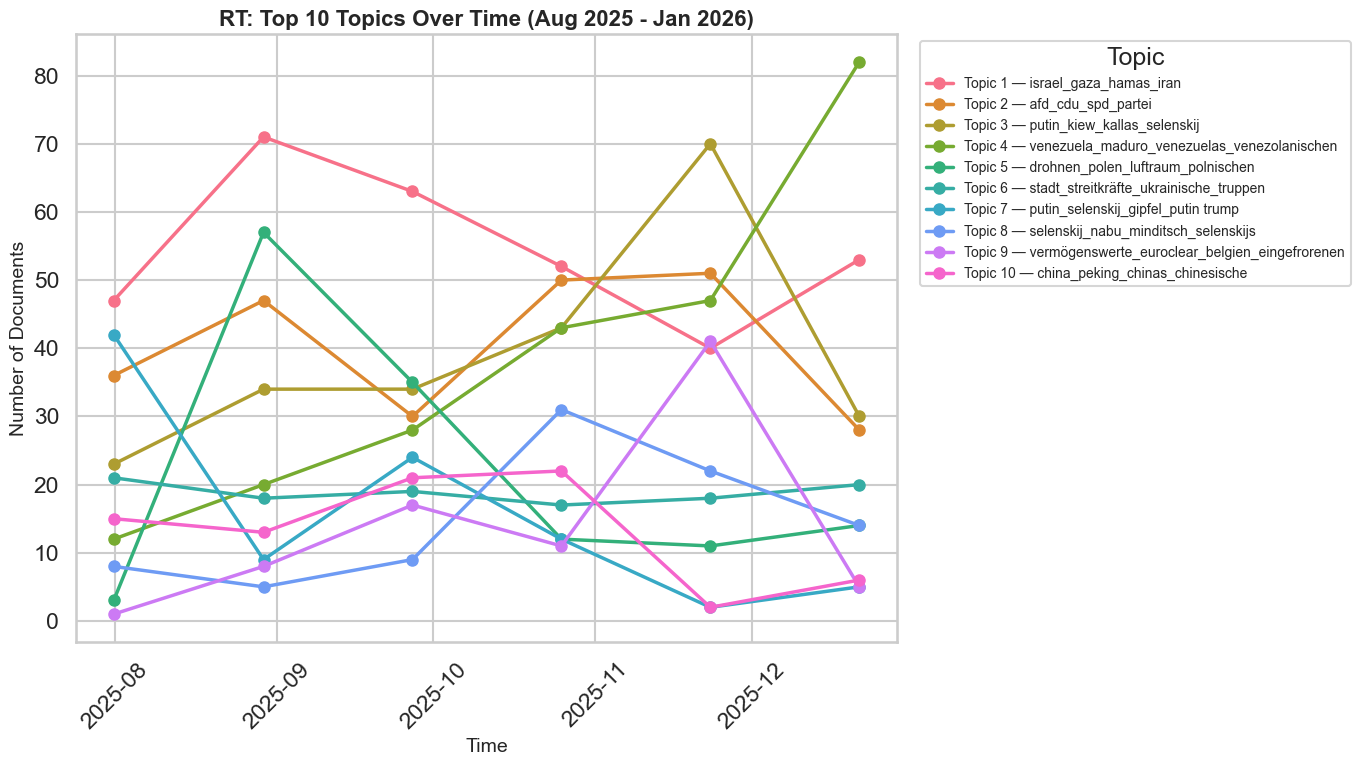

In [291]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_rt_reduced`.
topic_time_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [292]:
from pathlib import Path
import pandas as pd
from bertopic import BERTopic

MODEL_DIR = Path("/Users/MattisHaumann/Dev/Thesis/1a_BERTopic/outputs/rt_model")
TOP_K = 30

topic_model = BERTopic.load(
    str(MODEL_DIR),
    embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

topic_info = topic_model.get_topic_info().copy()
display(topic_info[["Topic", "Count", "Name"]].head(20))

# Top keywords for every topic
topic_keywords = []
for topic_id in topic_info["Topic"]:
    terms = topic_model.get_topic(int(topic_id)) or []
    topic_keywords.append({
        "Topic": int(topic_id),
        "Count": int(topic_info.loc[topic_info["Topic"] == topic_id, "Count"].iloc[0]),
        "Name": topic_info.loc[topic_info["Topic"] == topic_id, "Name"].iloc[0],
        "Top_Keywords": ", ".join([word for word, _ in terms[:TOP_K]])
    })

topic_keywords_df = pd.DataFrame(topic_keywords).sort_values(["Topic"])
display(topic_keywords_df)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name
0,-1,552,-1_berlin_stadt_kinder_soros
1,0,326,0_israel_gaza_hamas_iran
2,1,232,1_venezuela_maduro_venezuelas_venezolanischen
3,2,242,2_afd_cdu_spd_partei
4,3,234,3_putin_kiew_kallas_selenskij
5,4,132,4_drohnen_polen_luftraum_polnischen
6,5,89,5_selenskij_nabu_minditsch_selenskijs
7,6,113,6_stadt_streitkräfte_ukrainische_truppen
8,7,94,7_putin_selenskij_gipfel_putin trump
9,8,69,8_trumps_kiew_putin_selenskij


,Topic,Count,Name,Top_Keywords
0,-1,552,-1_berlin_stadt_kinder_soros,"berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeite..."
1,0,326,0_israel_gaza_hamas_iran,"israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, iranische, geiseln, teheran, idf, iranischen, palästinensisc..."
2,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, machado, drogen, maduros, trumps, kuba, drogenhan..."
3,2,242,2_afd_cdu_spd_partei,"afd, cdu, spd, partei, bsw, grünen, corona, weidel, habeck, demokratie, bundestag, merz, parteien, kandidaten, bank, stimmen, umfrage, chrupalla, fraktion, ..."
4,3,234,3_putin_kiew_kallas_selenskij,"putin, kiew, kallas, selenskij, russen, armee, ukrainische, streitkräfte, ukrainer, gegen russland, konflikts, truppen, europas, verhandlungen, wladimir put..."
...,...,...,...,...
70,69,16,69_zwei plus_plus vier_plus_vier vertrag,"zwei plus, plus vier, plus, vier vertrag, vertrag, berlin, bundeswehr, ddr, soldaten, atomwaffen, deutschlands, wehrpflicht, deutscher, souveränität, stegne..."
71,70,28,70_bundeswehr_wehrdienst_wehrpflicht_musterung,"bundeswehr, wehrdienst, wehrpflicht, musterung, pistorius, reservisten, soldaten, losverfahren, jungen, mad, männer, freiwilligen, spd, bundestag, wehrdiens..."
72,71,18,71_schüler_schule_schulen_kinder,"schüler, schule, schulen, kinder, deutsch, lehrer, hochdeutsch, deutschkenntnisse, eltern, österreich, zertifikate, lehrkräfte, unterricht, litauen, lehrkrä..."
73,72,23,72_serbien_vučić_beitritt_serbischen,"serbien, vučić, beitritt, serbischen, belgrad, serbische, eu beitritt, serbiens, eu mitgliedschaft, mitgliedschaft, europäischen union, aufnahme, ungarns, o..."


In [293]:
import pandas as pd

run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt

topic_info = run_result["topic_info"].copy()
doc_info = run_result["doc_info"].copy()

outlier_count = int((doc_info["Topic"] == -1).sum())
total_docs = len(doc_info)
outlier_share = outlier_count / total_docs if total_docs else 0

print(f"Outliers: {outlier_count} / {total_docs} ({outlier_share:.1%})")

display(
    topic_info.loc[topic_info["Topic"] == -1, ["Topic", "Count", "Name", "Representation"]]
)


Outliers: 552 / 4560 (12.1%)


,Topic,Count,Name,Representation
0,-1,552,-1_berlin_stadt_kinder_soros,"[berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeit..."


In [294]:
outliers = doc_info.loc[doc_info["Topic"] == -1].copy()

cols = [c for c in ["document_id", "Title", "Date", "source_name", "Name", "document"] if c in outliers.columns]
display(outliers[cols].head(30))


,document_id,Title,Date,source_name,Name
3,5324,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,2026-01-19,RT_de,-1_berlin_stadt_kinder_soros
34,5355,Schweiz: St. Gallen plant Impfpflicht mit Bußgeldern bis zu 20.000 Franken,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
39,5360,Das ZDF im Schattenkrieg,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
47,5368,Moskau: Kiew hält zwölf Zivilisten aus Kursk als Geiseln fest,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
51,5372,Deutschland: Gewerkschaften kündigen Ausweitung der Warnstreiks im öffentlichen Dienst an,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
53,5374,Russische Spezialisten wehren Invasion im Herzen Afrikas ab,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
54,5375,Powerbanks bei vielen Fluglinien streng beschränkt – jetzt auch bei Lufthansa,2026-01-17,RT_de,-1_berlin_stadt_kinder_soros
67,5388,"Politico-Bericht: EU-Außenbeauftragte Kaja Kallas meint, es wäre ""Zeit, sich zu betrinken""",2026-01-16,RT_de,-1_berlin_stadt_kinder_soros
87,5408,"""Steadfast Dart 26"" – NATO-Mitglieder beginnen in Deutschland die größte ""Verlegeübung"" des Jahres",2026-01-15,RT_de,-1_berlin_stadt_kinder_soros
92,5413,Spionage-Verdacht: Russland weist Mitarbeiter der britischen Botschaft aus,2026-01-15,RT_de,-1_berlin_stadt_kinder_soros


In [295]:
import pandas as pd
import re
from collections import Counter

run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt

docs = list(run_result["docs"])
topics = list(run_result["topics"])

outlier_docs = [doc for doc, topic in zip(docs, topics) if topic == -1]

print(f"Outlier docs: {len(outlier_docs)} / {len(docs)} ({len(outlier_docs)/len(docs):.1%})")

tokens = []
for text in outlier_docs:
    tokens.extend(re.findall(r"\b\w{4,}\b", str(text).lower()))

common = pd.DataFrame(Counter(tokens).most_common(50), columns=["word", "freq"])
display(common)


Outlier docs: 552 / 4560 (12.1%)


,word,freq
0,dass,1520
1,eine,1498
2,sich,1486
3,nicht,1472
4,auch,1090
5,werden,964
6,nach,867
7,einer,857
8,über,812
9,wird,725


In [296]:
topic_model = result_rt["topic_model"]
topic_info = result_rt["topic_info"].copy()

display(topic_info.head(30))

,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_berlin_stadt_kinder_soros,-1,552,-1_berlin_stadt_kinder_soros,"[berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeit...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,1,Topic 1 — israel_gaza_hamas_iran,israel_gaza_hamas_iran,0,326,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, iranische, geiseln, teheran, idf, iranischen, palästinensis...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,4,Topic 4 — venezuela_maduro_venezuelas_venezolanischen,venezuela_maduro_venezuelas_venezolanischen,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, machado, drogen, maduros, trumps, kuba, drogenha...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,2,Topic 2 — afd_cdu_spd_partei,afd_cdu_spd_partei,2,242,2_afd_cdu_spd_partei,"[afd, cdu, spd, partei, bsw, grünen, corona, weidel, habeck, demokratie, bundestag, merz, parteien, kandidaten, bank, stimmen, umfrage, chrupalla, fraktion,...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,3,Topic 3 — putin_kiew_kallas_selenskij,putin_kiew_kallas_selenskij,3,234,3_putin_kiew_kallas_selenskij,"[putin, kiew, kallas, selenskij, russen, armee, ukrainische, streitkräfte, ukrainer, gegen russland, konflikts, truppen, europas, verhandlungen, wladimir pu...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,5,Topic 5 — drohnen_polen_luftraum_polnischen,drohnen_polen_luftraum_polnischen,4,132,4_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeug, gps, ukrainische, vorfall, polnische, russische drohnen, flugzeuge, bundeswehr, einsatz, abgeschoss...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,8,Topic 8 — selenskij_nabu_minditsch_selenskijs,selenskij_nabu_minditsch_selenskijs,5,89,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, korruption, jermak, korruptionsskandal, ukrainische, kolomoiski, kiew, timur, energoatom, wladimir selenskij, umero...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,6,Topic 6 — stadt_streitkräfte_ukrainische_truppen,stadt_streitkräfte_ukrainische_truppen,6,113,6_stadt_streitkräfte_ukrainische_truppen,"[stadt, streitkräfte, ukrainische, truppen, ukrainischen streitkräfte, pokrowsk, kupjansk, saporoschje, gebiet, front, konstantinowka, liman, slawjansk, fro...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,7,Topic 7 — putin_selenskij_gipfel_putin trump,putin_selenskij_gipfel_putin trump,7,94,7_putin_selenskij_gipfel_putin trump,"[putin, selenskij, gipfel, putin trump, budapest, alaska, wladimir putin, gipfeltreffen, stattfinden, verhandlungen, staatschefs, uschakow, konflikts, treff...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Reg

In [298]:
topic_model = result_rt["topic_model"]

In [299]:
run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_model = run_result["topic_model"]


In [301]:
topic_info = topic_model.get_topic_info().copy()
display(topic_info.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,552,-1_berlin_stadt_kinder_soros,"[berlin, stadt, kinder, soros, putin, soldaten, rheinmetall, bahn, polizei, russen, österreich, bundesregierung, wef, china, gericht, ki, einsatz, mitarbeit...","[Europa sucht nach ""Kanonenfutter"" für die ukrainische Armee. Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten..."
1,0,326,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, netanjahu, israelische, gazastreifen, israels, un, iranische, geiseln, teheran, idf, iranischen, palästinensis...",[Gerecht? Israel mit Trumps 20-Punkte-Plan für Gaza einverstanden – Zustimmung der Hamas noch offen. Nach ihrer gestrigen dreistündigen Unterredung im Weiße...
2,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, machado, drogen, maduros, trumps, kuba, drogenha...",[Medien: Trump kündigt diplomatische Konfliktlösung mit Venezuela auf – Regime Change droht. Präsident Trump hat laut US-Beamten die Bemühungen um eine dipl...
3,2,242,2_afd_cdu_spd_partei,"[afd, cdu, spd, partei, bsw, grünen, corona, weidel, habeck, demokratie, bundestag, merz, parteien, kandidaten, bank, stimmen, umfrage, chrupalla, fraktion,...",[NRW-Stichwahlen: Kein AfD-Kandidat konnte siegen – SPD verliert historisch in Dortmund. Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Wes...
4,3,234,3_putin_kiew_kallas_selenskij,"[putin, kiew, kallas, selenskij, russen, armee, ukrainische, streitkräfte, ukrainer, gegen russland, konflikts, truppen, europas, verhandlungen, wladimir pu...","[Europa bewegt USA zu militärischer Eskalation – Russland bereit, Herausforderung anzunehmen. Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wlad..."
5,4,132,4_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeug, gps, ukrainische, vorfall, polnische, russische drohnen, flugzeuge, bundeswehr, einsatz, abgeschoss...","[NATO-Generalsekretär: ""Rücksichtsloses Verhalten"", egal ob es absichtlich war oder nicht. Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren..."
6,5,89,5_selenskij_nabu_minditsch_selenskijs,"[selenskij, nabu, minditsch, selenskijs, korruption, jermak, korruptionsskandal, ukrainische, kolomoiski, kiew, timur, energoatom, wladimir selenskij, umero...",[Warum der Korruptionsskandal in der Ukraine eine große Gefahr für Selenskij darstellt. Die ukrainischen Anti-Korruptionsermittler haben die Büchse der Pand...
7,6,113,6_stadt_streitkräfte_ukrainische_truppen,"[stadt, streitkräfte, ukrainische, truppen, ukrainischen streitkräfte, pokrowsk, kupjansk, saporoschje, gebiet, front, konstantinowka, liman, slawjansk, fro...","[Die Ukraine ist überfordert: Russlands Offensiven verwandeln Schwachstellen in Bruchstellen. Von Sergei Poletajew Als der August dem September wich, ändert..."
8,7,94,7_putin_selenskij_gipfel_putin trump,"[putin, selenskij, gipfel, putin trump, budapest, alaska, wladimir putin, gipfeltreffen, stattfinden, verhandlungen, staatschefs, uschakow, konflikts, treff...",[EU will bei Putin-Trump-Gipfel mitreden: Stubb soll nach Budapest reisen. Die Staats- und Regierungschefs der Europäischen Union wollen bei dem bevorstehen...
9,8,69,8_trumps_kiew_putin_selenskij,"[trumps, kiew, putin, selenskij, weißen, haus, europäer, medwedew, weißen haus, papiertiger, verhandlungen, konflikts, us präsidenten, trump hat, präsident ...","[Ukraine – Trump setzt mit starkem Zug EU-NATO-Falken matt. Von Rainer Rupp Dank seiner Bereitschaft, direkte Gespräche mit der russischen Seite zu führen, ..."


In [303]:
topic_model = result_rt["topic_model"]

topic_id = 0   # change topic id
pd.DataFrame(topic_model.get_topic(topic_id), columns=["keyword", "weight"])


,keyword,weight
0,israel,0.032518
1,gaza,0.022071
2,hamas,0.019188
3,iran,0.017847
4,israelischen,0.016540
5,al,0.014290
6,netanjahu,0.013792
7,israelische,0.013662
8,gazastreifen,0.013619
9,israels,0.012794


In [304]:
topic_model = result_rt["topic_model"]

for topic_id in topic_model.get_topic_info()["Topic"]:
    print(f"\n=== Topic {topic_id} ===")
    display(pd.DataFrame(topic_model.get_topic(int(topic_id)), columns=["keyword", "weight"]))



=== Topic -1 ===


,keyword,weight
0,berlin,0.002618
1,stadt,0.002428
2,kinder,0.002378
3,soros,0.002374
4,putin,0.002325
5,soldaten,0.002322
6,rheinmetall,0.002248
7,bahn,0.002197
8,polizei,0.002188
9,russen,0.001958



=== Topic 0 ===


,keyword,weight
0,israel,0.032518
1,gaza,0.022071
2,hamas,0.019188
3,iran,0.017847
4,israelischen,0.016540
5,al,0.014290
6,netanjahu,0.013792
7,israelische,0.013662
8,gazastreifen,0.013619
9,israels,0.012794



=== Topic 1 ===


...

,keyword,weight
0,schüler,0.026856
1,schule,0.023461
2,schulen,0.023323
3,kinder,0.019893
4,deutsch,0.018542
5,lehrer,0.015884
6,hochdeutsch,0.014300
7,deutschkenntnisse,0.013108
8,eltern,0.013066
9,österreich,0.012384



=== Topic 72 ===


,keyword,weight
0,serbien,0.062494
1,vučić,0.028339
2,beitritt,0.026107
3,serbischen,0.020881
4,belgrad,0.020296
5,serbische,0.019213
6,eu beitritt,0.018783
7,serbiens,0.016891
8,eu mitgliedschaft,0.014208
9,mitgliedschaft,0.013468



=== Topic 73 ===


,keyword,weight
0,ubs,0.111221
1,credit suisse,0.057398
2,credit,0.056965
3,suisse,0.056551
4,schweizer,0.037809
5,schweiz,0.035300
6,bank,0.030029
7,finma,0.028842
8,bundesrat,0.025438
9,snb,0.022620
